In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [24]:
BASE_DIR = Path.home() / "b200_dynamic_range_safe"

DETAILS_FILE = BASE_DIR / "dynamic_range_details.csv"
SUMMARY_FILE = BASE_DIR / "dynamic_range_summary.csv"

print("Fichier détaillé :", DETAILS_FILE)
print("Fichier résumé   :", SUMMARY_FILE)

print("Détails disponibles :", DETAILS_FILE.exists())
print("Résumé disponible   :", SUMMARY_FILE.exists())

Fichier détaillé : /home/yousef/b200_dynamic_range_safe/dynamic_range_details.csv
Fichier résumé   : /home/yousef/b200_dynamic_range_safe/dynamic_range_summary.csv
Détails disponibles : True
Résumé disponible   : True


In [25]:
details_df = pd.read_csv(DETAILS_FILE)
summary_df = pd.read_csv(SUMMARY_FILE)

print("Dimensions détails :", details_df.shape)
print("Dimensions résumé  :", summary_df.shape)

display(details_df.head())
display(summary_df.head())

Dimensions détails : (25900, 15)
Dimensions résumé  : (100, 17)


,frequency_hz,frequency_mhz,gain_db,attenuation_db,generator_dbm,input_rx2_dbm,total_power_linear,measured_dbfs,noise_power_linear,noise_dbfs,signal_power_linear,snr_db,peak_amplitude,clipping_fraction,detected
0,100000000.0,100.0,76.0,60.0,-20.0,-80.0,0.050233,-12.990111,0.000752,-31.235097,0.049481,18.179438,0.314568,0.0,True
1,100000000.0,100.0,76.0,60.0,-20.0,-80.0,0.050317,-12.982872,0.000752,-31.235097,0.049564,18.186786,0.305929,0.0,True
2,100000000.0,100.0,76.0,60.0,-20.0,-80.0,0.050332,-12.981546,0.000752,-31.235097,0.049580,18.188133,0.307045,0.0,True
3,100000000.0,100.0,76.0,60.0,-20.0,-80.0,0.050453,-12.971149,0.000752,-31.235097,0.049700,18.198687,0.307469,0.0,True
4,100000000.0,100.0,76.0,60.0,-20.0,-80.0,0.050335,-12.981262,0.000752,-31.235097,0.049583,18.188422,0.315571,0.0,True


,frequency_hz,frequency_mhz,gain_db,attenuation_db,generator_min_tested_dbm,generator_max_tested_dbm,rx2_min_tested_dbm,rx2_max_tested_dbm,noise_dbfs,minimum_detectable_dbm,pmin_status,maximum_linear_dbm,pmax_status,dynamic_range_db,linear_fit_slope,linear_fit_intercept,number_of_input_points
0,100000000.0,100.0,76.0,60.0,-20.0,20.0,-80.0,-40.0,-31.235097,-80.0,limite_basse_du_banc,NaN,aucun_point_lineaire,NaN,NaN,NaN,41
1,100000000.0,100.0,60.0,60.0,-20.0,20.0,-80.0,-40.0,-44.106292,-80.0,limite_basse_du_banc,-57.0,mesure_valide,23.0,0.994087,52.866568,41
2,200000000.0,200.0,76.0,60.0,-20.0,20.0,-80.0,-40.0,-31.918207,-80.0,limite_basse_du_banc,NaN,aucun_point_lineaire,NaN,NaN,NaN,41
3,200000000.0,200.0,60.0,60.0,-20.0,20.0,-80.0,-40.0,-45.643760,-80.0,limite_basse_du_banc,-56.0,mesure_valide,24.0,0.991286,52.339881,41
4,300000000.0,300.0,76.0,60.0,-20.0,20.0,-80.0,-40.0,-32.154422,-80.0,limite_basse_du_banc,NaN,aucun_point_lineaire,NaN,NaN,NaN,41


In [26]:
print("Colonnes du tableau détaillé :")
for column in details_df.columns:
    print(" -", column)

print("\nColonnes du tableau résumé :")
for column in summary_df.columns:
    print(" -", column)

Colonnes du tableau détaillé :
 - frequency_hz
 - frequency_mhz
 - gain_db
 - attenuation_db
 - generator_dbm
 - input_rx2_dbm
 - total_power_linear
 - measured_dbfs
 - noise_power_linear
 - noise_dbfs
 - signal_power_linear
 - snr_db
 - peak_amplitude
 - clipping_fraction
 - detected

Colonnes du tableau résumé :
 - frequency_hz
 - frequency_mhz
 - gain_db
 - attenuation_db
 - generator_min_tested_dbm
 - generator_max_tested_dbm
 - rx2_min_tested_dbm
 - rx2_max_tested_dbm
 - noise_dbfs
 - minimum_detectable_dbm
 - pmin_status
 - maximum_linear_dbm
 - pmax_status
 - dynamic_range_db
 - linear_fit_slope
 - linear_fit_intercept
 - number_of_input_points


In [27]:
numeric_summary_columns = [
    "frequency_hz",
    "frequency_mhz",
    "gain_db",
    "attenuation_db",
    "noise_dbfs",
    "noise_estimated_dbm",
    "minimum_detectable_dbm",
    "maximum_linear_dbm",
    "dynamic_range_db",
]

for column in numeric_summary_columns:
    if column in summary_df.columns:
        summary_df[column] = pd.to_numeric(
            summary_df[column],
            errors="coerce",
        )

numeric_details_columns = [
    "frequency_hz",
    "gain_db",
    "attenuation_db",
    "generator_dbm",
    "input_dbm",
    "measured_dbfs",
    "estimated_dbm",
    "noise_dbfs",
    "snr_over_noise_db",
    "linearity_error_db",
    "peak_amplitude",
    "clipping_fraction",
]

for column in numeric_details_columns:
    if column in details_df.columns:
        details_df[column] = pd.to_numeric(
            details_df[column],
            errors="coerce",
        )

if "frequency_mhz" not in details_df.columns:
    details_df["frequency_mhz"] = (
        details_df["frequency_hz"] / 1e6
    )

summary_df = summary_df.sort_values(
    ["gain_db", "frequency_mhz"]
).reset_index(drop=True)

details_df = details_df.sort_values(
    ["gain_db", "frequency_mhz", "input_dbm"]
).reset_index(drop=True)

display(summary_df.head())

KeyError: 'input_dbm'

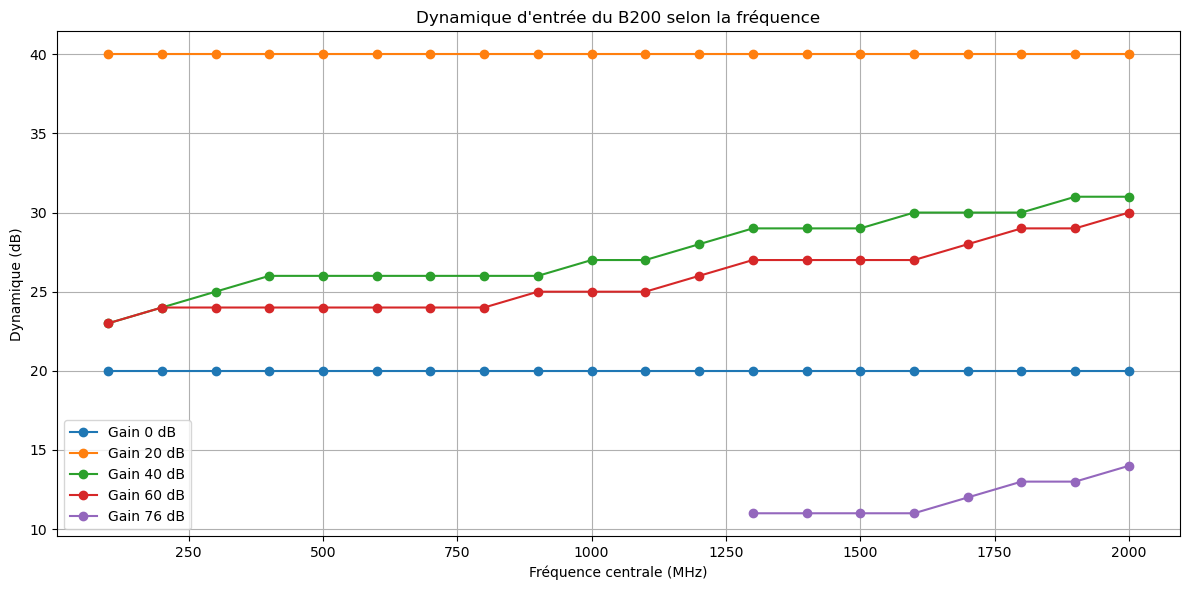

In [28]:
plt.figure(figsize=(12, 6))

for gain_db in sorted(summary_df["gain_db"].dropna().unique()):
    gain_data = summary_df[
        summary_df["gain_db"] == gain_db
    ].dropna(subset=["dynamic_range_db"])

    plt.plot(
        gain_data["frequency_mhz"],
        gain_data["dynamic_range_db"],
        marker="o",
        label=f"Gain {gain_db:.0f} dB",
    )

plt.title("Dynamique d'entrée du B200 selon la fréquence")
plt.xlabel("Fréquence centrale (MHz)")
plt.ylabel("Dynamique (dB)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
dynamic_by_gain = (
    summary_df
    .groupby("gain_db", as_index=False)
    .agg(
        dynamic_mean_db=("dynamic_range_db", "mean"),
        dynamic_min_db=("dynamic_range_db", "min"),
        dynamic_max_db=("dynamic_range_db", "max"),
        valid_points=("dynamic_range_db", "count"),
    )
)

display(dynamic_by_gain)

,gain_db,dynamic_mean_db,dynamic_min_db,dynamic_max_db,valid_points
0,0.0,20.00,20.0,20.0,20
1,20.0,40.00,40.0,40.0,20
2,40.0,27.45,23.0,31.0,20
3,60.0,25.80,23.0,30.0,20
4,76.0,12.00,11.0,14.0,8


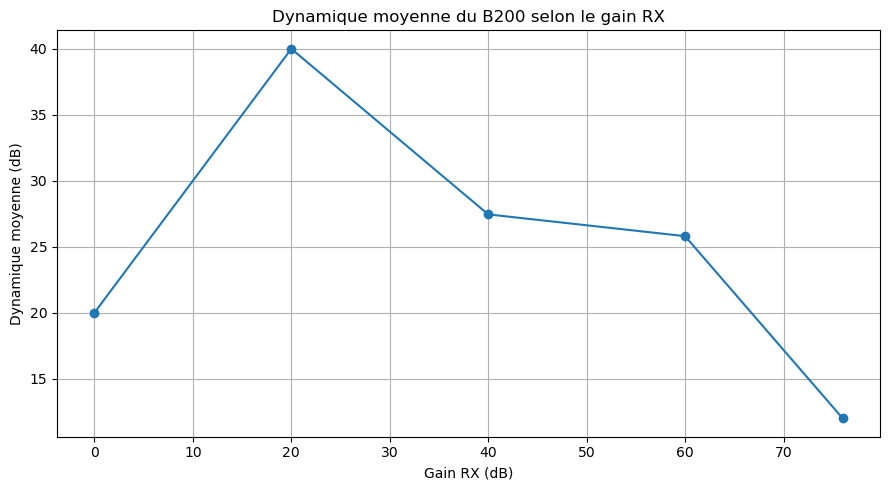

In [30]:
plt.figure(figsize=(9, 5))

plt.plot(
    dynamic_by_gain["gain_db"],
    dynamic_by_gain["dynamic_mean_db"],
    marker="o",
)

plt.title("Dynamique moyenne du B200 selon le gain RX")
plt.xlabel("Gain RX (dB)")
plt.ylabel("Dynamique moyenne (dB)")
plt.grid(True)
plt.tight_layout()
plt.show()

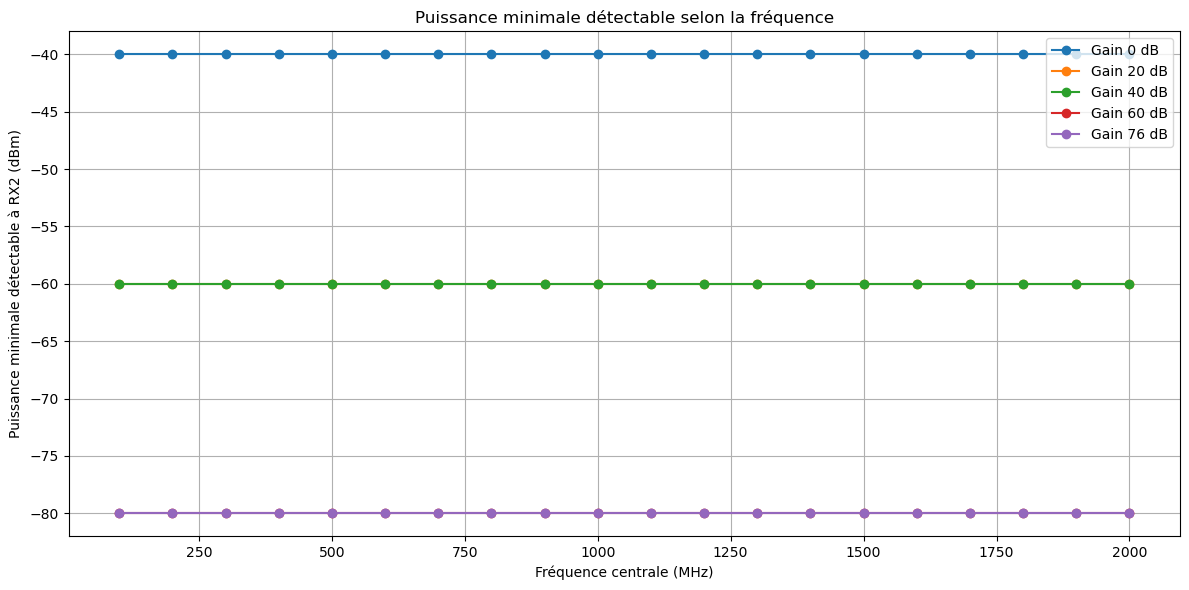

In [31]:
plt.figure(figsize=(12, 6))

for gain_db in sorted(summary_df["gain_db"].dropna().unique()):
    gain_data = summary_df[
        summary_df["gain_db"] == gain_db
    ].dropna(subset=["minimum_detectable_dbm"])

    plt.plot(
        gain_data["frequency_mhz"],
        gain_data["minimum_detectable_dbm"],
        marker="o",
        label=f"Gain {gain_db:.0f} dB",
    )

plt.title("Puissance minimale détectable selon la fréquence")
plt.xlabel("Fréquence centrale (MHz)")
plt.ylabel("Puissance minimale détectable à RX2 (dBm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

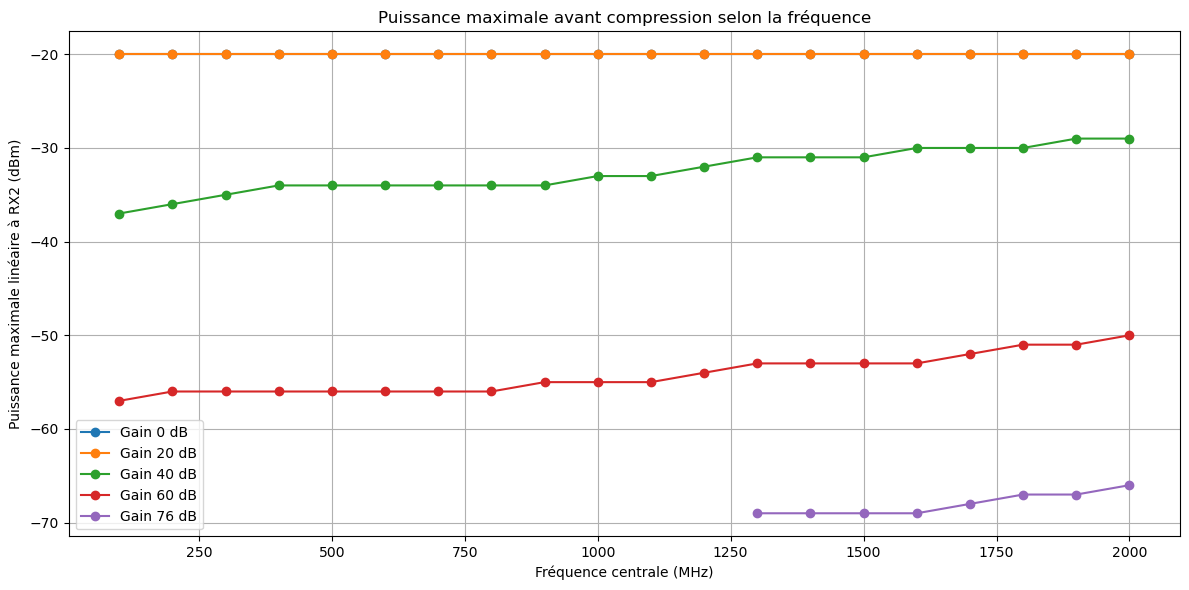

In [32]:
plt.figure(figsize=(12, 6))

for gain_db in sorted(summary_df["gain_db"].dropna().unique()):
    gain_data = summary_df[
        summary_df["gain_db"] == gain_db
    ].dropna(subset=["maximum_linear_dbm"])

    plt.plot(
        gain_data["frequency_mhz"],
        gain_data["maximum_linear_dbm"],
        marker="o",
        label=f"Gain {gain_db:.0f} dB",
    )

plt.title("Puissance maximale avant compression selon la fréquence")
plt.xlabel("Fréquence centrale (MHz)")
plt.ylabel("Puissance maximale linéaire à RX2 (dBm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
SELECTED_GAIN_DB = 40.0

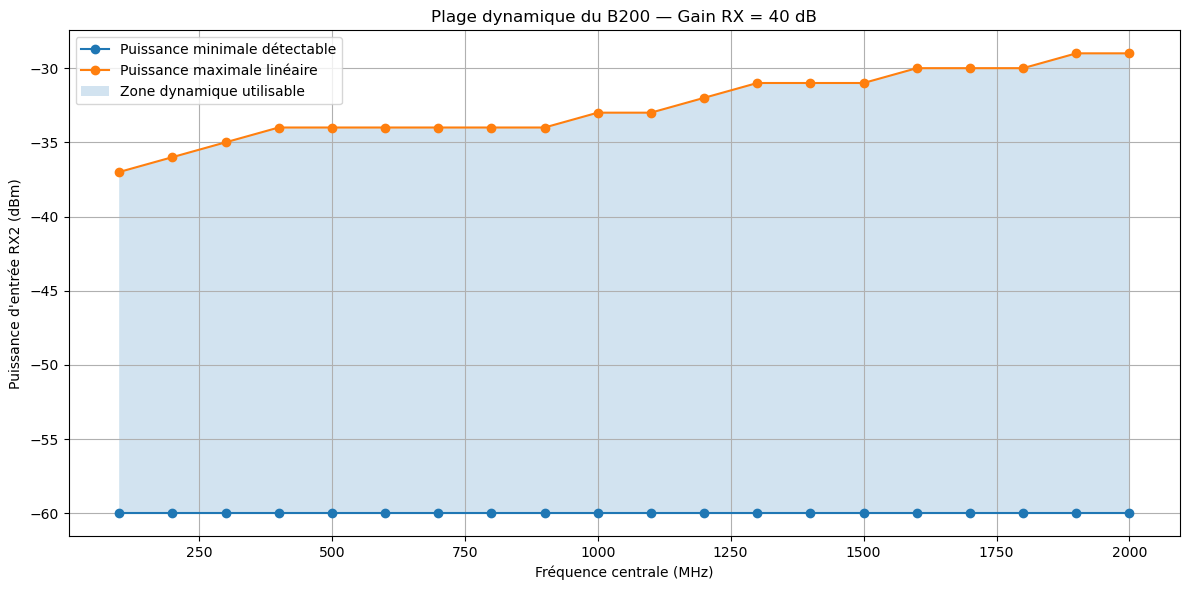

In [34]:
selected_summary = summary_df[
    summary_df["gain_db"] == SELECTED_GAIN_DB
].dropna(
    subset=[
        "minimum_detectable_dbm",
        "maximum_linear_dbm",
    ]
)

plt.figure(figsize=(12, 6))

plt.plot(
    selected_summary["frequency_mhz"],
    selected_summary["minimum_detectable_dbm"],
    marker="o",
    label="Puissance minimale détectable",
)

plt.plot(
    selected_summary["frequency_mhz"],
    selected_summary["maximum_linear_dbm"],
    marker="o",
    label="Puissance maximale linéaire",
)

plt.fill_between(
    selected_summary["frequency_mhz"],
    selected_summary["minimum_detectable_dbm"],
    selected_summary["maximum_linear_dbm"],
    alpha=0.2,
    label="Zone dynamique utilisable",
)

plt.title(
    f"Plage dynamique du B200 — Gain RX = {SELECTED_GAIN_DB:.0f} dB"
)
plt.xlabel("Fréquence centrale (MHz)")
plt.ylabel("Puissance d'entrée RX2 (dBm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

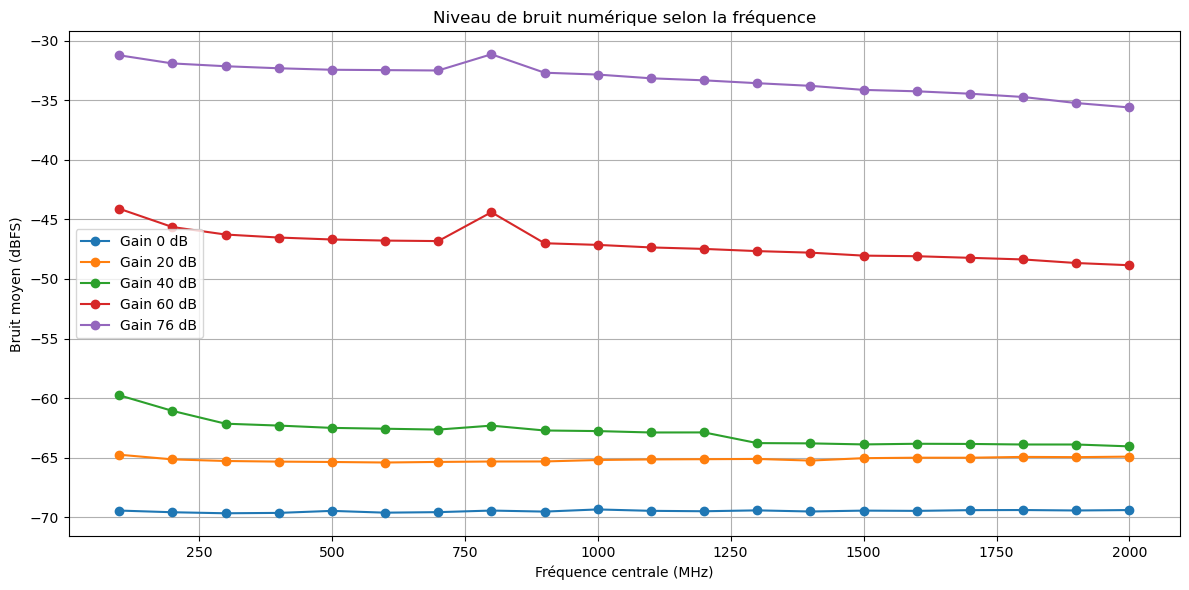

In [35]:
plt.figure(figsize=(12, 6))

for gain_db in sorted(summary_df["gain_db"].dropna().unique()):
    gain_data = summary_df[
        summary_df["gain_db"] == gain_db
    ].dropna(subset=["noise_dbfs"])

    plt.plot(
        gain_data["frequency_mhz"],
        gain_data["noise_dbfs"],
        marker="o",
        label=f"Gain {gain_db:.0f} dB",
    )

plt.title("Niveau de bruit numérique selon la fréquence")
plt.xlabel("Fréquence centrale (MHz)")
plt.ylabel("Bruit moyen (dBFS)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
plt.figure(figsize=(12, 6))

for gain_db in sorted(summary_df["gain_db"].dropna().unique()):
    gain_data = summary_df[
        summary_df["gain_db"] == gain_db
    ].dropna(subset=["noise_estimated_dbm"])

    plt.plot(
        gain_data["frequency_mhz"],
        gain_data["noise_estimated_dbm"],
        marker="o",
        label=f"Gain {gain_db:.0f} dB",
    )

plt.title("Bruit d'entrée estimé en dBm selon la fréquence")
plt.xlabel("Fréquence centrale (MHz)")
plt.ylabel("Bruit d'entrée estimé (dBm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

KeyError: ['noise_estimated_dbm']

<Figure size 1200x600 with 0 Axes>

In [37]:
dynamic_matrix = summary_df.pivot_table(
    index="gain_db",
    columns="frequency_mhz",
    values="dynamic_range_db",
    aggfunc="mean",
)

dynamic_matrix = dynamic_matrix.sort_index()
dynamic_matrix = dynamic_matrix.sort_index(axis=1)

display(dynamic_matrix)

frequency_mhz,100.0,200.0,300.0,400.0,500.0,600.0,700.0,800.0,900.0,1000.0,1100.0,1200.0,1300.0,1400.0,1500.0,1600.0,1700.0,1800.0,1900.0,2000.0
gain_db,,,,,,,,,,,,,,,,,,,,
0.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0,20.0
20.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0
40.0,23.0,24.0,25.0,26.0,26.0,26.0,26.0,26.0,26.0,27.0,27.0,28.0,29.0,29.0,29.0,30.0,30.0,30.0,31.0,31.0
60.0,23.0,24.0,24.0,24.0,24.0,24.0,24.0,24.0,25.0,25.0,25.0,26.0,27.0,27.0,27.0,27.0,28.0,29.0,29.0,30.0
76.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,11.0,11.0,11.0,12.0,13.0,13.0,14.0


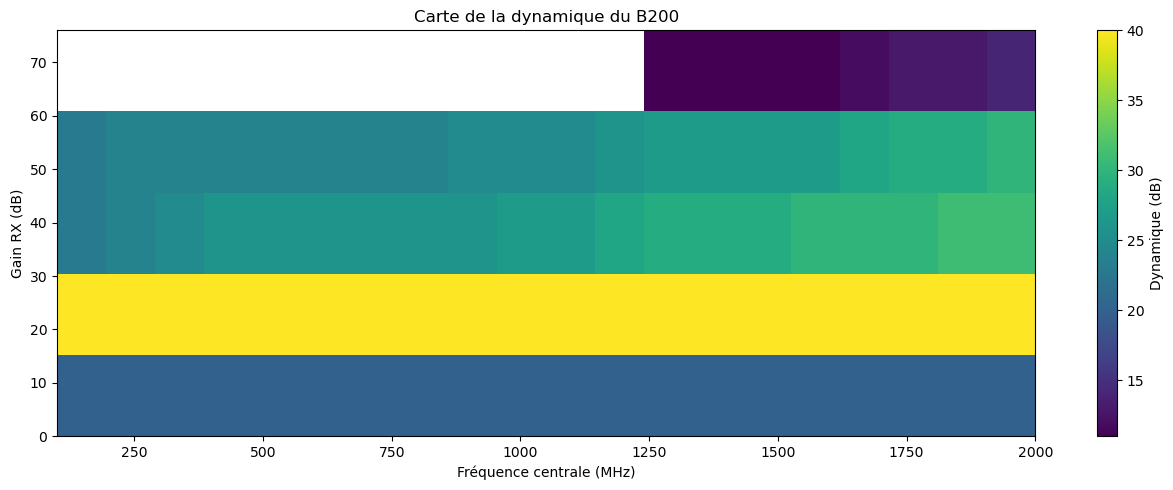

In [38]:
frequency_axis = dynamic_matrix.columns.to_numpy(dtype=float)
gain_axis = dynamic_matrix.index.to_numpy(dtype=float)
dynamic_values = dynamic_matrix.to_numpy(dtype=float)

plt.figure(figsize=(13, 5))

image = plt.imshow(
    dynamic_values,
    aspect="auto",
    origin="lower",
    extent=[
        frequency_axis.min(),
        frequency_axis.max(),
        gain_axis.min(),
        gain_axis.max(),
    ],
)

plt.colorbar(
    image,
    label="Dynamique (dB)",
)

plt.title("Carte de la dynamique du B200")
plt.xlabel("Fréquence centrale (MHz)")
plt.ylabel("Gain RX (dB)")
plt.tight_layout()
plt.show()

In [39]:
SELECTED_FREQUENCY_MHZ = 1000.0
SELECTED_GAIN_DB = 40.0

In [40]:
case_df = details_df[
    np.isclose(
        details_df["frequency_mhz"],
        SELECTED_FREQUENCY_MHZ,
    )
    & np.isclose(
        details_df["gain_db"],
        SELECTED_GAIN_DB,
    )
].copy()

case_df = case_df.sort_values("input_dbm")

print("Nombre de points :", len(case_df))
display(case_df)

KeyError: 'input_dbm'

In [41]:
plt.figure(figsize=(8, 6))

plt.plot(
    case_df["input_dbm"],
    case_df["estimated_dbm"],
    marker="o",
    label="Puissance estimée par le B200",
)

minimum_power = min(
    case_df["input_dbm"].min(),
    case_df["estimated_dbm"].min(),
)

maximum_power = max(
    case_df["input_dbm"].max(),
    case_df["estimated_dbm"].max(),
)

plt.plot(
    [minimum_power, maximum_power],
    [minimum_power, maximum_power],
    linestyle="--",
    label="Réponse idéale",
)

plt.title(
    f"Linéarité — {SELECTED_FREQUENCY_MHZ:.0f} MHz, "
    f"gain {SELECTED_GAIN_DB:.0f} dB"
)
plt.xlabel("Puissance réellement injectée à RX2 (dBm)")
plt.ylabel("Puissance estimée par calibration (dBm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

KeyError: 'input_dbm'

<Figure size 800x600 with 0 Axes>

In [42]:
plt.figure(figsize=(10, 5))

plt.plot(
    case_df["input_dbm"],
    case_df["linearity_error_db"],
    marker="o",
)

plt.axhline(
    1.0,
    linestyle="--",
    label="Limite +1 dB",
)

plt.axhline(
    -1.0,
    linestyle="--",
    label="Limite −1 dB",
)

plt.title(
    f"Erreur de linéarité — {SELECTED_FREQUENCY_MHZ:.0f} MHz, "
    f"gain {SELECTED_GAIN_DB:.0f} dB"
)
plt.xlabel("Puissance injectée à RX2 (dBm)")
plt.ylabel("Erreur estimée − injectée (dB)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

KeyError: 'input_dbm'

<Figure size 1000x500 with 0 Axes>

In [43]:
plt.figure(figsize=(10, 5))

plt.plot(
    case_df["input_dbm"],
    case_df["measured_dbfs"],
    marker="o",
    label="Niveau reçu",
)

noise_value = case_df["noise_dbfs"].median()

plt.axhline(
    noise_value,
    linestyle="--",
    label=f"Bruit = {noise_value:.2f} dBFS",
)

plt.axhline(
    noise_value + 6.0,
    linestyle="--",
    label="Seuil de détection = bruit + 6 dB",
)

plt.axhline(
    -3.0,
    linestyle="--",
    label="Limite proche saturation = −3 dBFS",
)

plt.title(
    f"Réponse numérique — {SELECTED_FREQUENCY_MHZ:.0f} MHz, "
    f"gain {SELECTED_GAIN_DB:.0f} dB"
)
plt.xlabel("Puissance injectée à RX2 (dBm)")
plt.ylabel("Puissance numérique mesurée (dBFS)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

KeyError: 'input_dbm'

<Figure size 1000x500 with 0 Axes>

In [44]:
detected_points = case_df[
    case_df["is_detected"].astype(str).str.lower().isin(
        ["true", "1"]
    )
]

linear_points = case_df[
    case_df["is_linear"].astype(str).str.lower().isin(
        ["true", "1"]
    )
]

plt.figure(figsize=(10, 5))

plt.scatter(
    case_df["input_dbm"],
    case_df["measured_dbfs"],
    label="Tous les points",
)

plt.scatter(
    detected_points["input_dbm"],
    detected_points["measured_dbfs"],
    marker="s",
    label="Points détectés",
)

plt.scatter(
    linear_points["input_dbm"],
    linear_points["measured_dbfs"],
    marker="x",
    s=80,
    label="Points détectés et linéaires",
)

plt.title(
    f"Classification des points — {SELECTED_FREQUENCY_MHZ:.0f} MHz, "
    f"gain {SELECTED_GAIN_DB:.0f} dB"
)
plt.xlabel("Puissance injectée à RX2 (dBm)")
plt.ylabel("Niveau mesuré (dBFS)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

KeyError: 'is_detected'

In [45]:
final_table = summary_df[
    [
        "frequency_mhz",
        "gain_db",
        "noise_dbfs",
        "noise_estimated_dbm",
        "minimum_detectable_dbm",
        "maximum_linear_dbm",
        "dynamic_range_db",
        "status",
    ]
].copy()

final_table.columns = [
    "Fréquence (MHz)",
    "Gain RX (dB)",
    "Bruit (dBFS)",
    "Bruit estimé (dBm)",
    "Pmin détectable (dBm)",
    "Pmax linéaire (dBm)",
    "Dynamique (dB)",
    "État",
]

numeric_columns = [
    "Fréquence (MHz)",
    "Gain RX (dB)",
    "Bruit (dBFS)",
    "Bruit estimé (dBm)",
    "Pmin détectable (dBm)",
    "Pmax linéaire (dBm)",
    "Dynamique (dB)",
]

for column in numeric_columns:
    final_table[column] = pd.to_numeric(
        final_table[column],
        errors="coerce",
    )

display(
    final_table.round(
        {
            "Fréquence (MHz)": 1,
            "Gain RX (dB)": 1,
            "Bruit (dBFS)": 2,
            "Bruit estimé (dBm)": 2,
            "Pmin détectable (dBm)": 2,
            "Pmax linéaire (dBm)": 2,
            "Dynamique (dB)": 2,
        }
    )
)

KeyError: "['noise_estimated_dbm', 'status'] not in index"

In [46]:
statistics_by_gain = (
    summary_df
    .groupby("gain_db")
    .agg(
        dynamique_moyenne_db=("dynamic_range_db", "mean"),
        dynamique_minimale_db=("dynamic_range_db", "min"),
        dynamique_maximale_db=("dynamic_range_db", "max"),
        sensibilite_moyenne_dbm=(
            "minimum_detectable_dbm",
            "mean",
        ),
        puissance_max_moyenne_dbm=(
            "maximum_linear_dbm",
            "mean",
        ),
    )
    .reset_index()
)

# S'assurer que les colonnes sont numériques
numeric_columns = [
    "gain_db",
    "dynamique_moyenne_db",
    "dynamique_minimale_db",
    "dynamique_maximale_db",
    "sensibilite_moyenne_dbm",
    "puissance_max_moyenne_dbm",
]

for column in numeric_columns:
    statistics_by_gain[column] = pd.to_numeric(
        statistics_by_gain[column],
        errors="coerce",
    )

display(
    statistics_by_gain.round(
        {
            "gain_db": 1,
            "dynamique_moyenne_db": 2,
            "dynamique_minimale_db": 2,
            "dynamique_maximale_db": 2,
            "sensibilite_moyenne_dbm": 2,
            "puissance_max_moyenne_dbm": 2,
        }
    )
)

,gain_db,dynamique_moyenne_db,dynamique_minimale_db,dynamique_maximale_db,sensibilite_moyenne_dbm,puissance_max_moyenne_dbm
0,0.0,20.00,20.0,20.0,-40.0,-20.00
1,20.0,40.00,40.0,40.0,-60.0,-20.00
2,40.0,27.45,23.0,31.0,-60.0,-32.55
3,60.0,25.80,23.0,30.0,-80.0,-54.20
4,76.0,12.00,11.0,14.0,-80.0,-68.00


In [47]:
FINAL_TABLE_FILE = (
    BASE_DIR
    / "dynamic_range_final_table.csv"
)

final_table.to_csv(
    FINAL_TABLE_FILE,
    index=False,
)

print("Tableau final enregistré dans :")
print(FINAL_TABLE_FILE)

NameError: name 'final_table' is not defined